# Flood Prediction for Hue and Quang Nam

This notebook loads 3 trained models for D+1, D+2, and D+3, then predicts flood risk for both Hue and Quang Nam.


In [1]:
import os
import requests
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from datetime import timedelta


## 1. Load trained models and feature list


In [2]:
MODEL_DIR = "../models"

model_d1 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d1.pkl")
)

model_d2 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d2.pkl")
)

model_d3 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d3.pkl")
)

model_features = joblib.load(
    os.path.join(MODEL_DIR, "model_features.pkl")
)

models = {
    "D+1": model_d1,
    "D+2": model_d2,
    "D+3": model_d3
}

print("Loaded models successfully")

for horizon, model in models.items():
    print(horizon, "->", type(model).__name__)

print("\nModel features:")
print(model_features)


Loaded models successfully
D+1 -> XGBClassifier
D+2 -> XGBClassifier
D+3 -> XGBClassifier

Model features:
['location_id', 'rainfall', 'temperature', 'humidity', 'pressure', 'wind_speed', 'river_discharge', 'month', 'rainfall_3d', 'rainfall_7d', 'discharge_change_1d']


## 2. Define both prediction locations


In [3]:
locations = {
    "Hue": {
        "latitude": 16.4637,
        "longitude": 107.5909
    },

    "Quang Nam": {
        "latitude": 15.5736,
        "longitude": 108.4740
    }
}

locations


{'Hue': {'latitude': 16.4637, 'longitude': 107.5909},
 'Quang Nam': {'latitude': 15.5736, 'longitude': 108.474}}

## 3. Load location_id mapping from training data


In [4]:
TRAIN_DATA_PATH = "../data/train/train_data.csv"

train_reference = pd.read_csv(
    TRAIN_DATA_PATH,
    usecols=[
        "location_id",
        "location"
    ]
).drop_duplicates()

location_mapping = dict(
    zip(
        train_reference["location"],
        train_reference["location_id"]
    )
)

print("Location mapping:")

for location, location_id in location_mapping.items():
    print(location, "->", location_id)


Location mapping:
Hue -> 1
Quang Nam -> 2


## 4. Weather API function


In [5]:
def get_weather_data(latitude, longitude):

    weather_url = (
        "https://api.open-meteo.com/v1/forecast"
    )

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,

        "daily": [
            "temperature_2m_mean",
            "relative_humidity_2m_mean",
            "precipitation_sum",
            "pressure_msl_mean",
            "wind_speed_10m_max"
        ],

        "past_days": 7,
        "forecast_days": 1,
        "timezone": "Asia/Bangkok"
    }

    response = requests.get(
        weather_url,
        params=weather_params,
        timeout=30
    )

    response.raise_for_status()

    weather_data = response.json()

    weather_df = pd.DataFrame({
        "date": weather_data["daily"]["time"],
        "rainfall": weather_data["daily"]["precipitation_sum"],
        "temperature": weather_data["daily"]["temperature_2m_mean"],
        "humidity": weather_data["daily"]["relative_humidity_2m_mean"],
        "pressure": weather_data["daily"]["pressure_msl_mean"],
        "wind_speed": weather_data["daily"]["wind_speed_10m_max"]
    })

    weather_df["date"] = pd.to_datetime(
        weather_df["date"]
    )

    return weather_df


## 5. River discharge API function


In [6]:
def get_river_data(latitude, longitude):

    flood_url = (
        "https://flood-api.open-meteo.com/v1/flood"
    )

    flood_params = {
        "latitude": latitude,
        "longitude": longitude,

        "daily": [
            "river_discharge"
        ],

        "past_days": 7,
        "forecast_days": 1,
        "timezone": "Asia/Bangkok"
    }

    response = requests.get(
        flood_url,
        params=flood_params,
        timeout=30
    )

    response.raise_for_status()

    flood_data = response.json()

    river_df = pd.DataFrame({
        "date": flood_data["daily"]["time"],
        "river_discharge": flood_data["daily"]["river_discharge"]
    })

    river_df["date"] = pd.to_datetime(
        river_df["date"]
    )

    return river_df


## 6. Feature engineering function


In [7]:
def create_features(
    weather_df,
    river_df,
    location_id
):

    data = (
        weather_df
        .merge(
            river_df,
            on="date",
            how="inner"
        )
        .sort_values("date")
        .reset_index(drop=True)
    )

    data["location_id"] = location_id

    data["month"] = (
        data["date"]
        .dt.month
    )

    data["rainfall_3d"] = (
        data["rainfall"]
        .rolling(
            window=3,
            min_periods=3
        )
        .sum()
    )

    data["rainfall_7d"] = (
        data["rainfall"]
        .rolling(
            window=7,
            min_periods=7
        )
        .sum()
    )

    data["discharge_change_1d"] = (
        data["river_discharge"]
        .diff(1)
    )

    return data


## 7. Alert level function


In [8]:
def get_alert_level(score):

    if score < 20:
        return "Green"

    elif score < 40:
        return "Yellow"

    elif score < 60:
        return "Orange"

    elif score < 80:
        return "Red"

    else:
        return "Severe Red"


## 8. River trend function


In [9]:
def get_river_trend(change):

    if change > 10:
        return "Increasing"

    elif change < -10:
        return "Decreasing"

    else:
        return "Stable"


## 9. Risk factors function


In [10]:
def get_risk_factors(row):

    risk_factors = []

    if row["rainfall"] > 50:
        risk_factors.append(
            "Heavy rainfall"
        )

    if row["rainfall_3d"] > 100:
        risk_factors.append(
            "High accumulated rainfall in 3 days"
        )

    if row["rainfall_7d"] > 200:
        risk_factors.append(
            "High accumulated rainfall in 7 days"
        )

    if row["discharge_change_1d"] > 10:
        risk_factors.append(
            "Increasing river discharge"
        )

    if not risk_factors:
        risk_factors.append(
            "No major risk factor detected"
        )

    return risk_factors


## 10. Recommendation function


In [11]:
def get_recommendation(score):

    if score < 20:
        return (
            "Normal condition. "
            "Continue monitoring."
        )

    elif score < 40:
        return (
            "Low risk. "
            "Monitor weather updates."
        )

    elif score < 60:
        return (
            "Moderate risk. "
            "Prepare emergency supplies."
        )

    elif score < 80:
        return (
            "High risk. "
            "Avoid low-lying areas and riverside roads."
        )

    else:
        return (
            "Severe risk. "
            "Prepare evacuation and follow official warnings."
        )


## 11. Predict D+1, D+2, D+3 for both locations


In [12]:
all_results = []

for location_name, info in locations.items():

    print("=" * 60)
    print("Predicting:", location_name)
    print("=" * 60)

    lat = info["latitude"]
    lon = info["longitude"]

    if location_name not in location_mapping:
        raise ValueError(
            f"Cannot find location_id for {location_name}"
        )

    location_id = int(
        location_mapping[location_name]
    )

    # Get weather and river data
    weather_df = get_weather_data(
        lat,
        lon
    )

    river_df = get_river_data(
        lat,
        lon
    )

    # Create features
    data = create_features(
        weather_df,
        river_df,
        location_id
    )

    # Select the latest day with complete engineered features
    target_day = (
        data
        .dropna(
            subset=[
                "rainfall_3d",
                "rainfall_7d",
                "discharge_change_1d"
            ]
        )
        .tail(1)
        .copy()
    )

    if target_day.empty:
        print(
            "Not enough data for:",
            location_name
        )
        continue

    # Check model features
    missing_features = [
        feature
        for feature in model_features
        if feature not in target_day.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features for {location_name}: "
            f"{missing_features}"
        )

    input_data = (
        target_day[
            model_features
        ]
        .copy()
    )

    base_date = pd.to_datetime(
        target_day["date"].iloc[0]
    )

    current_row = target_day.iloc[0]

    river_change = float(
        current_row[
            "discharge_change_1d"
        ]
    )

    river_trend = get_river_trend(
        river_change
    )

    risk_factors = get_risk_factors(
        current_row
    )

    # Predict D+1, D+2, D+3
    for horizon, model in models.items():

        probability = float(
            model.predict_proba(
                input_data
            )[0, 1]
        )

        predicted_class = int(
            model.predict(
                input_data
            )[0]
        )

        risk_score = round(
            probability * 100,
            2
        )

        alert_level = get_alert_level(
            risk_score
        )

        recommendation = get_recommendation(
            risk_score
        )

        day_number = int(
            horizon.replace(
                "D+",
                ""
            )
        )

        forecast_date = (
            base_date
            + timedelta(
                days=day_number
            )
        )

        confidence = max(
            probability,
            1 - probability
        )

        result = {
            "location": location_name,
            "base_date": base_date.date(),
            "forecast_date": forecast_date.date(),
            "forecast_horizon": horizon,
            "predicted_flood": predicted_class,
            "flood_probability": round(
                probability,
                4
            ),
            "flood_risk_score": risk_score,
            "confidence_score": round(
                confidence * 100,
                2
            ),
            "alert_level": alert_level,
            "river_trend": river_trend,
            "main_risk_factors": ", ".join(
                risk_factors
            ),
            "recommendation": recommendation
        }

        all_results.append(
            result
        )


Predicting: Hue
Predicting: Quang Nam


## 12. Final results


In [13]:
results_df = pd.DataFrame(
    all_results
)

results_df


,location,base_date,forecast_date,forecast_horizon,predicted_flood,flood_probability,flood_risk_score,confidence_score,alert_level,river_trend,main_risk_factors,recommendation
0,Hue,2026-07-22,2026-07-23,D+1,0,0.0026,0.26,99.74,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
1,Hue,2026-07-22,2026-07-24,D+2,0,0.0156,1.56,98.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
2,Hue,2026-07-22,2026-07-25,D+3,0,0.0183,1.83,98.17,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
3,Quang Nam,2026-07-22,2026-07-23,D+1,0,0.0569,5.69,94.31,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
4,Quang Nam,2026-07-22,2026-07-24,D+2,0,0.0356,3.56,96.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
5,Quang Nam,2026-07-22,2026-07-25,D+3,0,0.0142,1.42,98.58,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.


## 13. Compact summary


In [14]:
summary_columns = [
    "location",
    "forecast_date",
    "forecast_horizon",
    "predicted_flood",
    "flood_probability",
    "flood_risk_score",
    "confidence_score",
    "alert_level"
]

results_df[
    summary_columns
]


,location,forecast_date,forecast_horizon,predicted_flood,flood_probability,flood_risk_score,confidence_score,alert_level
0,Hue,2026-07-23,D+1,0,0.0026,0.26,99.74,Green
1,Hue,2026-07-24,D+2,0,0.0156,1.56,98.44,Green
2,Hue,2026-07-25,D+3,0,0.0183,1.83,98.17,Green
3,Quang Nam,2026-07-23,D+1,0,0.0569,5.69,94.31,Green
4,Quang Nam,2026-07-24,D+2,0,0.0356,3.56,96.44,Green
5,Quang Nam,2026-07-25,D+3,0,0.0142,1.42,98.58,Green


## 14. Hue results


In [15]:
hue_results = (
    results_df[
        results_df[
            "location"
        ] == "Hue"
    ]
)

hue_results


,location,base_date,forecast_date,forecast_horizon,predicted_flood,flood_probability,flood_risk_score,confidence_score,alert_level,river_trend,main_risk_factors,recommendation
0,Hue,2026-07-22,2026-07-23,D+1,0,0.0026,0.26,99.74,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
1,Hue,2026-07-22,2026-07-24,D+2,0,0.0156,1.56,98.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
2,Hue,2026-07-22,2026-07-25,D+3,0,0.0183,1.83,98.17,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.


## 15. Quang Nam results


In [16]:
quang_nam_results = (
    results_df[
        results_df[
            "location"
        ] == "Quang Nam"
    ]
)

quang_nam_results


,location,base_date,forecast_date,forecast_horizon,predicted_flood,flood_probability,flood_risk_score,confidence_score,alert_level,river_trend,main_risk_factors,recommendation
3,Quang Nam,2026-07-22,2026-07-23,D+1,0,0.0569,5.69,94.31,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
4,Quang Nam,2026-07-22,2026-07-24,D+2,0,0.0356,3.56,96.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
5,Quang Nam,2026-07-22,2026-07-25,D+3,0,0.0142,1.42,98.58,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.


## 16. Compare 3-day flood risk between two locations


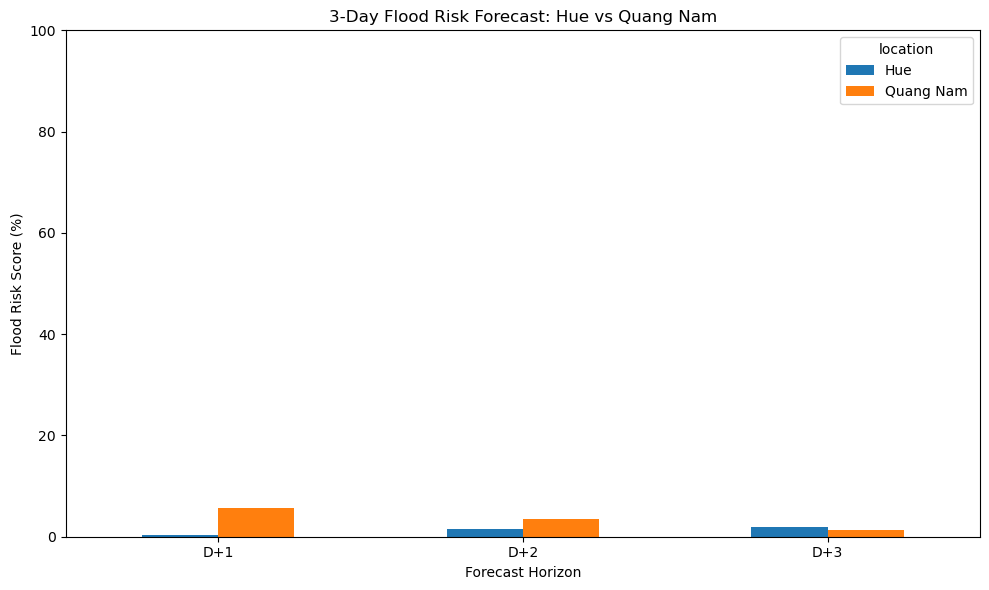

In [17]:
pivot_risk = (
    results_df
    .pivot(
        index="forecast_horizon",
        columns="location",
        values="flood_risk_score"
    )
    .reindex([
        "D+1",
        "D+2",
        "D+3"
    ])
)

pivot_risk.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(
    0,
    100
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "Flood Risk Score (%)"
)

plt.title(
    "3-Day Flood Risk Forecast: Hue vs Quang Nam"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


## 17. Readable forecast output


In [18]:
for location in locations.keys():

    print(
        "\n" + "=" * 70
    )

    print(
        "3-DAY FLOOD FORECAST:",
        location.upper()
    )

    print(
        "=" * 70
    )

    location_results = (
        results_df[
            results_df[
                "location"
            ] == location
        ]
    )

    for _, row in location_results.iterrows():

        print(
            f"\n{row['forecast_horizon']} - {row['forecast_date']}"
        )

        print(
            f"Flood Probability : "
            f"{row['flood_probability']:.2%}"
        )

        print(
            f"Risk Score        : "
            f"{row['flood_risk_score']:.2f}%"
        )

        print(
            f"Alert Level       : "
            f"{row['alert_level']}"
        )

        print(
            f"River Trend       : "
            f"{row['river_trend']}"
        )

        print(
            f"Risk Factors      : "
            f"{row['main_risk_factors']}"
        )

        print(
            f"Recommendation    : "
            f"{row['recommendation']}"
        )



3-DAY FLOOD FORECAST: HUE

D+1 - 2026-07-23
Flood Probability : 0.26%
Risk Score        : 0.26%
Alert Level       : Green
River Trend       : Stable
Risk Factors      : No major risk factor detected
Recommendation    : Normal condition. Continue monitoring.

D+2 - 2026-07-24
Flood Probability : 1.56%
Risk Score        : 1.56%
Alert Level       : Green
River Trend       : Stable
Risk Factors      : No major risk factor detected
Recommendation    : Normal condition. Continue monitoring.

D+3 - 2026-07-25
Flood Probability : 1.83%
Risk Score        : 1.83%
Alert Level       : Green
River Trend       : Stable
Risk Factors      : No major risk factor detected
Recommendation    : Normal condition. Continue monitoring.

3-DAY FLOOD FORECAST: QUANG NAM

D+1 - 2026-07-23
Flood Probability : 5.69%
Risk Score        : 5.69%
Alert Level       : Green
River Trend       : Stable
Risk Factors      : No major risk factor detected
Recommendation    : Normal condition. Continue monitoring.

D+2 - 2026-

In [24]:
final_table = results_df.rename(
    columns={
        "forecast_horizon": "horizon",
        "flood_probability": "flood_prob",
        "flood_risk_score": "risk_score",
        "confidence_score": "confidence",
        "main_risk_factors": "risk_factors"
    }
)

final_table = final_table[
    [
        "location",
        "base_date",
        "forecast_date",
        "horizon",
        "flood_prob",
        "risk_score",
        "confidence",
        "alert_level",
        "river_trend",
        "risk_factors",
        "recommendation"
    ]
]

final_table

,location,base_date,forecast_date,horizon,flood_prob,risk_score,confidence,alert_level,river_trend,risk_factors,recommendation
0,Hue,2026-07-22,2026-07-23,D+1,0.0026,0.26,99.74,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
1,Hue,2026-07-22,2026-07-24,D+2,0.0156,1.56,98.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
2,Hue,2026-07-22,2026-07-25,D+3,0.0183,1.83,98.17,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
3,Quang Nam,2026-07-22,2026-07-23,D+1,0.0569,5.69,94.31,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
4,Quang Nam,2026-07-22,2026-07-24,D+2,0.0356,3.56,96.44,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
5,Quang Nam,2026-07-22,2026-07-25,D+3,0.0142,1.42,98.58,Green,Stable,No major risk factor detected,Normal condition. Continue monitoring.
